In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('data_science_job.csv')

In [4]:
data.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
data.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [6]:
data.shape

(19158, 13)

In [7]:
col = [col for col in data.columns if data[col].isnull().mean() < 0.05 and data[col].isnull().mean() > 0]

col

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
new_df = data[col].copy()
new_df.sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
16109,0.920,no_enrollment,Graduate,10.0,165.0
7591,0.949,no_enrollment,Graduate,20.0,190.0
15451,0.884,Part time course,Graduate,9.0,65.0
15811,0.920,no_enrollment,High School,2.0,13.0
11598,0.558,Part time course,Masters,5.0,87.0


In [9]:
len(data[col].dropna())/len(data[col])

0.8968577095730244

In [11]:
print("Shape after removing NaN data: ", data[col].dropna().shape)
print("Shape before removing NaN data: ", data[col].shape)

Shape after removing NaN data:  (17182, 5)
Shape before removing NaN data:  (19158, 5)


In [12]:
new_df = data[col].dropna()
new_df.isnull().sum()

city_development_index    0
enrolled_university       0
education_level           0
experience                0
training_hours            0
dtype: int64

In [13]:
new_df.info()

<class 'pandas.DataFrame'>
Index: 17182 entries, 0 to 19157
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  17182 non-null  float64
 1   enrolled_university     17182 non-null  str    
 2   education_level         17182 non-null  str    
 3   experience              17182 non-null  float64
 4   training_hours          17182 non-null  float64
dtypes: float64(3), str(2)
memory usage: 1.1 MB


array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

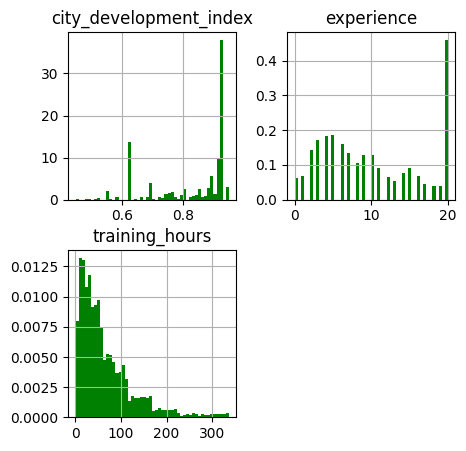

In [14]:
new_df.hist(bins=50, density=True, color='green', figsize=(5,5))

## Checking data distribution after applying CCA

### For experience

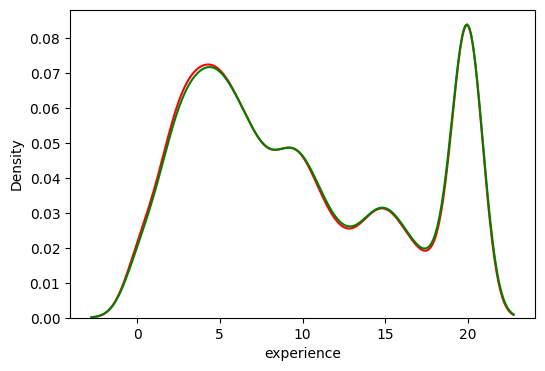

In [15]:

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
sns.kdeplot(data['experience'], color='red')
sns.kdeplot(new_df['experience'], color='green')
plt.show()

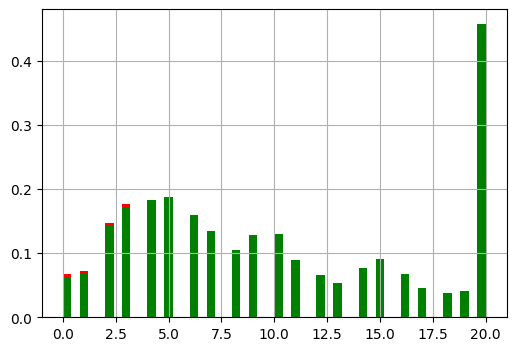

In [16]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['experience'].hist(bins=50, ax=ax, density=True, color='red')

new_df['experience'].hist(bins=50, ax=ax, density=True, color='green')

plt.show()

### for city_development_index

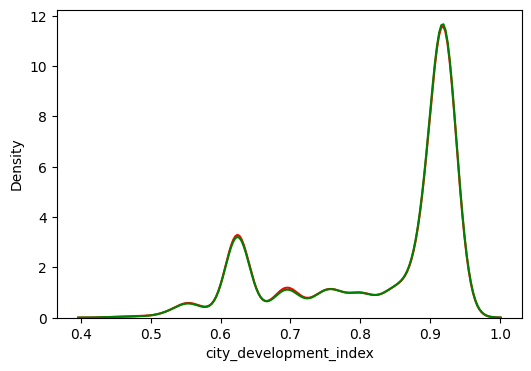

In [17]:
# for city_development_index
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
sns.kdeplot(data['city_development_index'], color='red')
sns.kdeplot(new_df['city_development_index'], color='green')
plt.show()

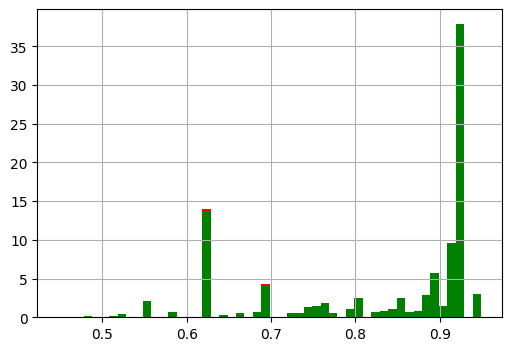

In [18]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

data['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')
new_df['city_development_index'].hist(bins=50, ax=ax, density=True, color='green')

plt.show()

### for training_hours

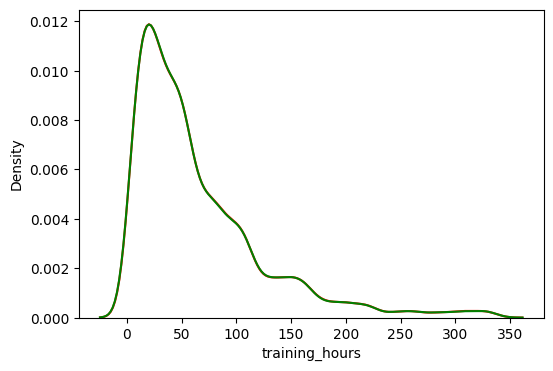

In [19]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
sns.kdeplot(data['training_hours'], color='red')
sns.kdeplot(new_df['training_hours'], color='green')
plt.show()

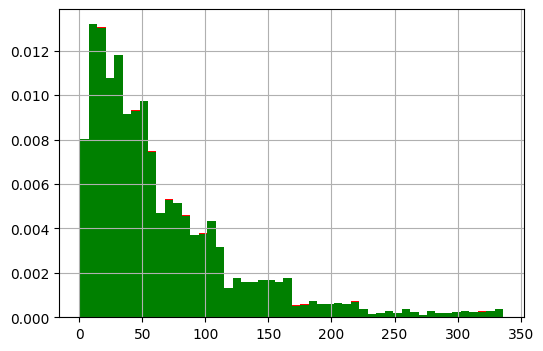

In [20]:
fig= plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

data['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green')

plt.show()